#### 1. Imports and setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
import sys
sys.path.append('../src')
from data_loader import EconomyDataLoader

# Sets a global visual theme for plots
sns.set_style("whitegrid")
# Sets the default figure size for all plots
plt.rcParams['figure.figsize'] = (14, 6)
# Tells Jupyter to render plots directly inside the notebook output cell
%matplotlib inline
# Sets the output resolution of inline plots
%config InlineBackend.figure_format = 'retina'

#### 2. Load Raw Data

In [2]:
loader = EconomyDataLoader(economy='usa')

# build_raw_dataset originally retrieves data that goes 5y before the start_date so that the dataset after feature engineering would
# start more or less at the start_date
start_date = '2000-01-01'
df_raw_offset = loader.build_raw_dataset(start_date = start_date)

n = 0
while True:
    try:
        df_raw = df_raw_offset.iloc[df_raw_offset[df_raw_offset['date'] == (pd.to_datetime(start_date) + timedelta(days = n))].index[0]:]
        break
    except:
        n += 1

print(f"Dataset shape: {df_raw.shape}")
print(f"Date range: {datetime.strftime(df_raw['date'].min(), '%Y-%m-%d')} to {datetime.strftime(df_raw['date'].max(), '%Y-%m-%d')}")
df_raw.head()

Dataset shape: (5809, 23)
Date range: 2002-12-18 to 2025-12-22


,date,PCE_Price,Real_GDP,Fed_Funds_Rate,Housing_Starts,Industrial_Production,M2_Money_Stock,Consumer_Sentiment,NFP,Fed_Assets,...,10Y_yield_2y_yield,Crude_Oil,VIX,yield_2y,yield_10y,yield_5y,yield_30y,SP500,Gold,USD_Index
0,2002-12-18,76.971,14537.58,1.24,1788.0,90.4652,5779.4,86.7,130465.0,719542.0,...,2.25,30.41,28.29,1.81,4.06,3.03,5.20,891.119995,342.100006,103.629997
1,2002-12-19,76.971,14537.58,1.24,1788.0,90.4652,5779.4,86.7,130465.0,719542.0,...,2.22,30.57,30.21,1.74,3.96,2.91,5.15,884.250000,345.899994,103.480003
2,2002-12-20,76.971,14537.58,1.24,1788.0,90.4652,5779.4,86.7,130465.0,719542.0,...,2.21,30.57,26.71,1.76,3.97,2.93,5.12,895.760010,340.500000,103.459999
3,2002-12-23,76.971,14537.58,1.24,1788.0,90.4652,5779.4,86.7,130465.0,719542.0,...,2.19,32.09,26.20,1.79,3.98,2.95,5.13,897.380005,345.100006,103.639999
4,2002-12-24,76.971,14537.58,1.24,1788.0,90.4652,5779.4,86.7,130465.0,719542.0,...,2.22,32.13,26.49,1.73,3.95,2.92,5.11,892.469971,346.799988,103.250000


#### 3. Data Quality Assessment

In [3]:
print("General Overview")
print(df_raw.info())

print("\nBasic Statistics:")
df_raw.describe().T

General Overview
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5809 entries, 0 to 5808
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   5809 non-null   datetime64[ns]
 1   PCE_Price              5809 non-null   float64       
 2   Real_GDP               5809 non-null   float64       
 3   Fed_Funds_Rate         5809 non-null   float64       
 4   Housing_Starts         5809 non-null   float64       
 5   Industrial_Production  5809 non-null   float64       
 6   M2_Money_Stock         5809 non-null   float64       
 7   Consumer_Sentiment     5809 non-null   float64       
 8   NFP                    5809 non-null   float64       
 9   Fed_Assets             5809 non-null   float64       
 10  30Y_Mortg_Rate         5809 non-null   float64       
 11  Unemployment           5809 non-null   float64       
 12  Retail_Sales           5809 non-null   float6

,count,mean,min,25%,50%,75%,max,std
date,5809,2014-06-12 19:45:10.070579968,2002-12-18 00:00:00,2008-09-04 00:00:00,2014-06-12 00:00:00,2020-03-18 00:00:00,2025-12-22 00:00:00,NaN
PCE_Price,5809.0,98.228699,76.971,88.593,96.987,104.271,127.625,13.37389
Real_GDP,5809.0,18776.516414,14537.58,16611.69,18185.911,20709.212,24024.957,2589.810787
Fed_Funds_Rate,5809.0,1.755893,0.05,0.13,1.01,3.08,5.33,1.888752
Housing_Starts,5809.0,1268.138062,478.0,973.0,1272.0,1543.0,2273.0,432.573612
Industrial_Production,5809.0,98.057897,84.5619,95.8568,99.3897,101.0993,104.1004,4.332733
M2_Money_Stock,5809.0,12594.97991,5779.4,7872.4,11382.8,15993.4,22298.1,5385.708584
Consumer_Sentiment,5809.0,80.16533,50.0,70.3,81.2,92.1,103.8,13.386267
NFP,5809.0,141574.996041,129705.0,133748.0,138391.0,149206.0,159593.0,9128.686153
Fed_Assets,5809.0,3902261.459632,712809.0,922187.0,3936784.0,4668212.0,8965487.0,2578595.106097


#### 4. (Potential) Target Variable Analysis

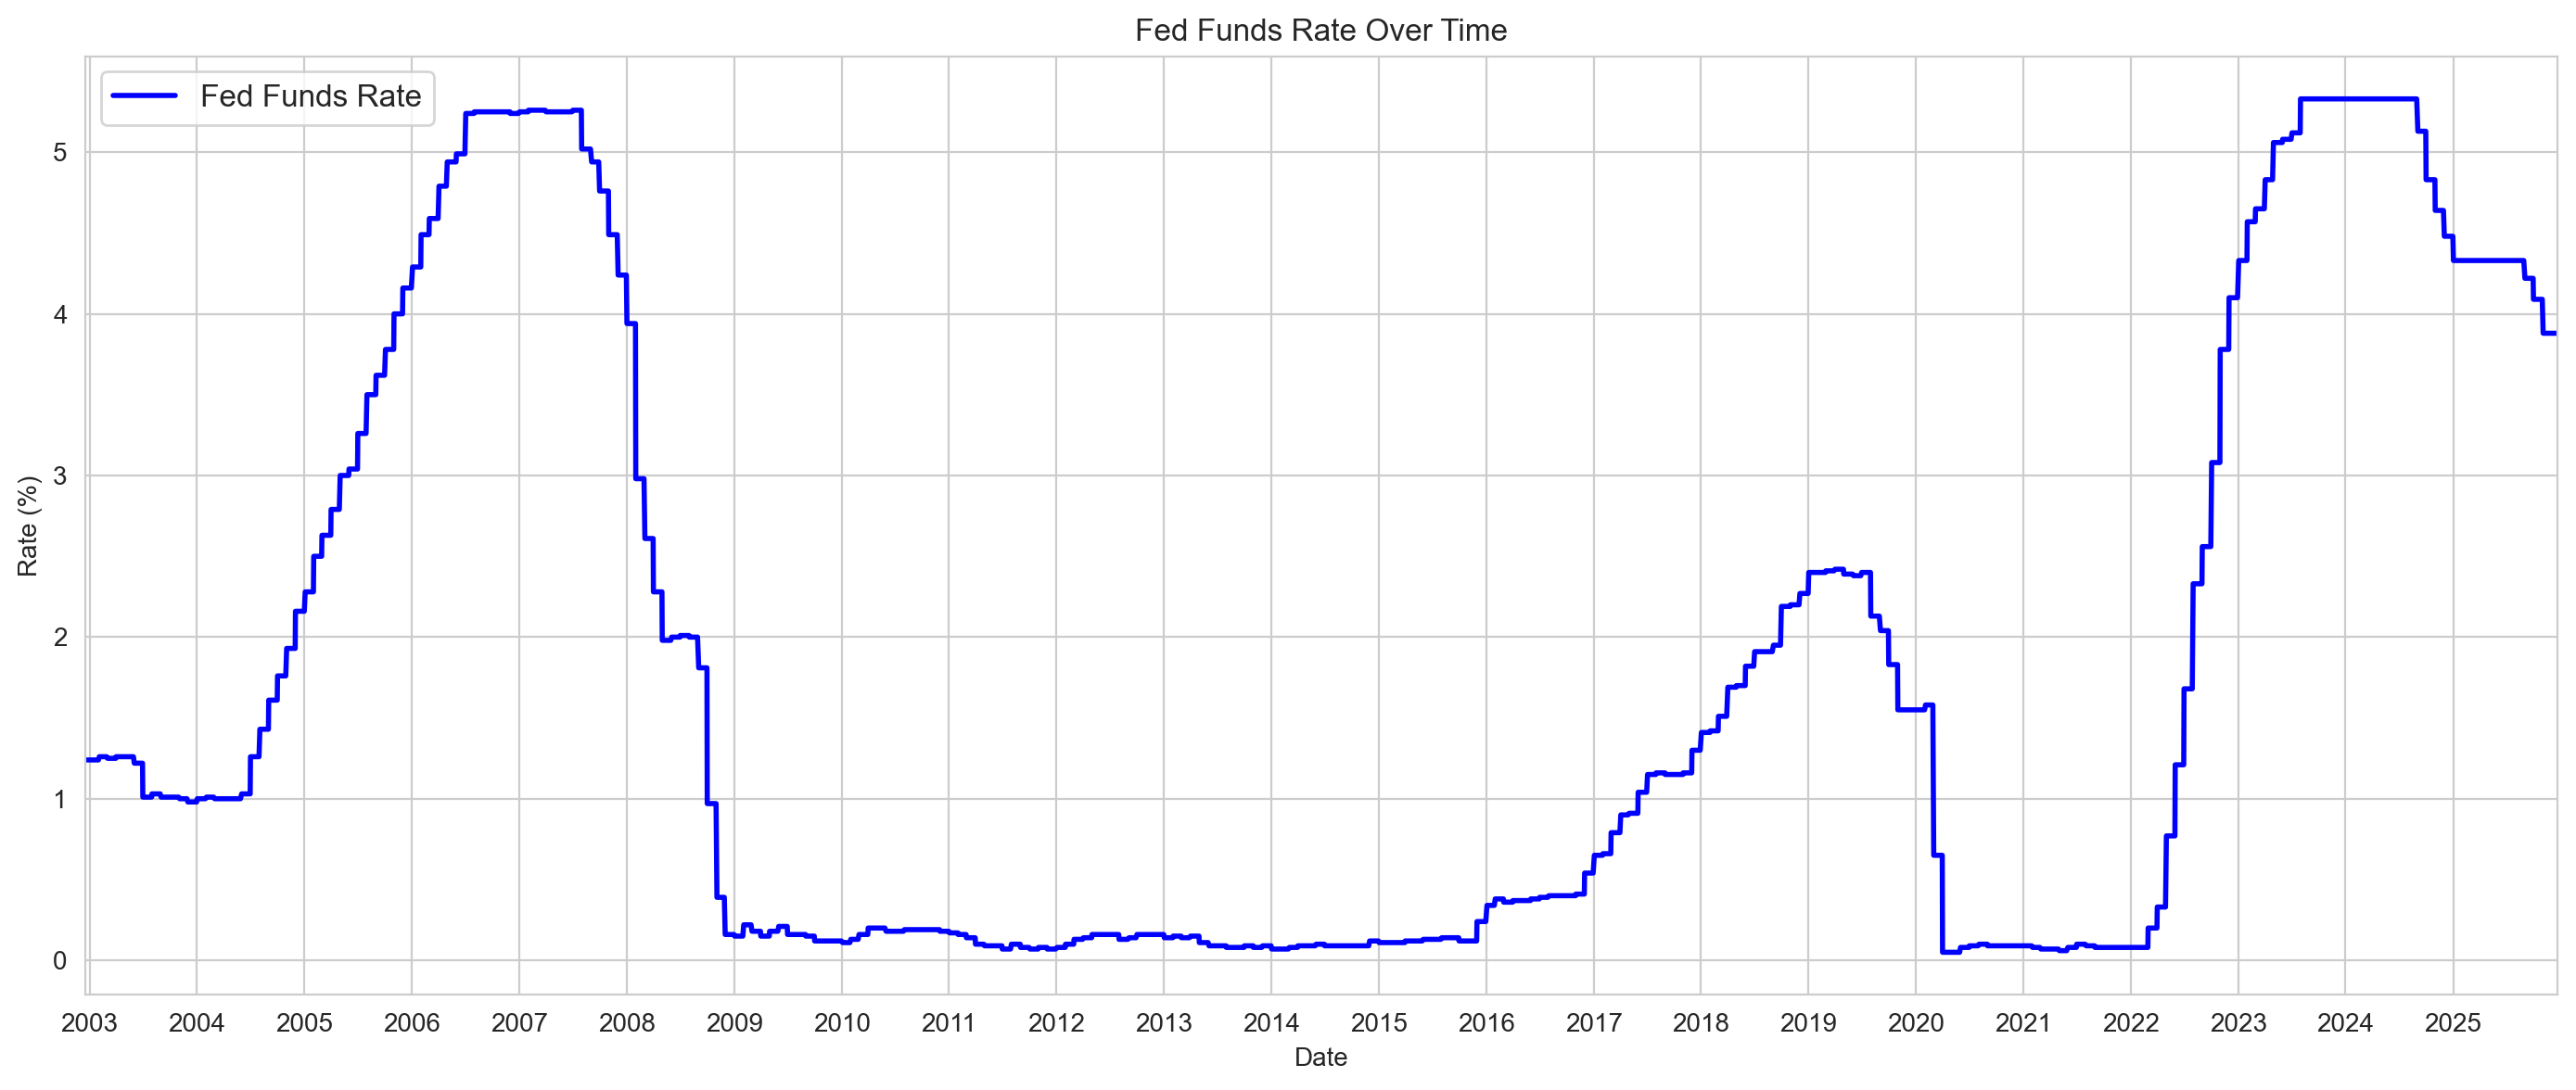

In [4]:
sns.lineplot(
    data=df_raw,
    x='date',
    y='Fed_Funds_Rate',
    linewidth=2,
    color='blue',
    label='Fed Funds Rate'
)

plt.title('Fed Funds Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Rate (%)')
plt.legend(fontsize = 12)
plt.xlim(df_raw['date'].min(), df_raw['date'].max())
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator(minticks=10, maxticks=25))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

#### 5. Distribution Analysis

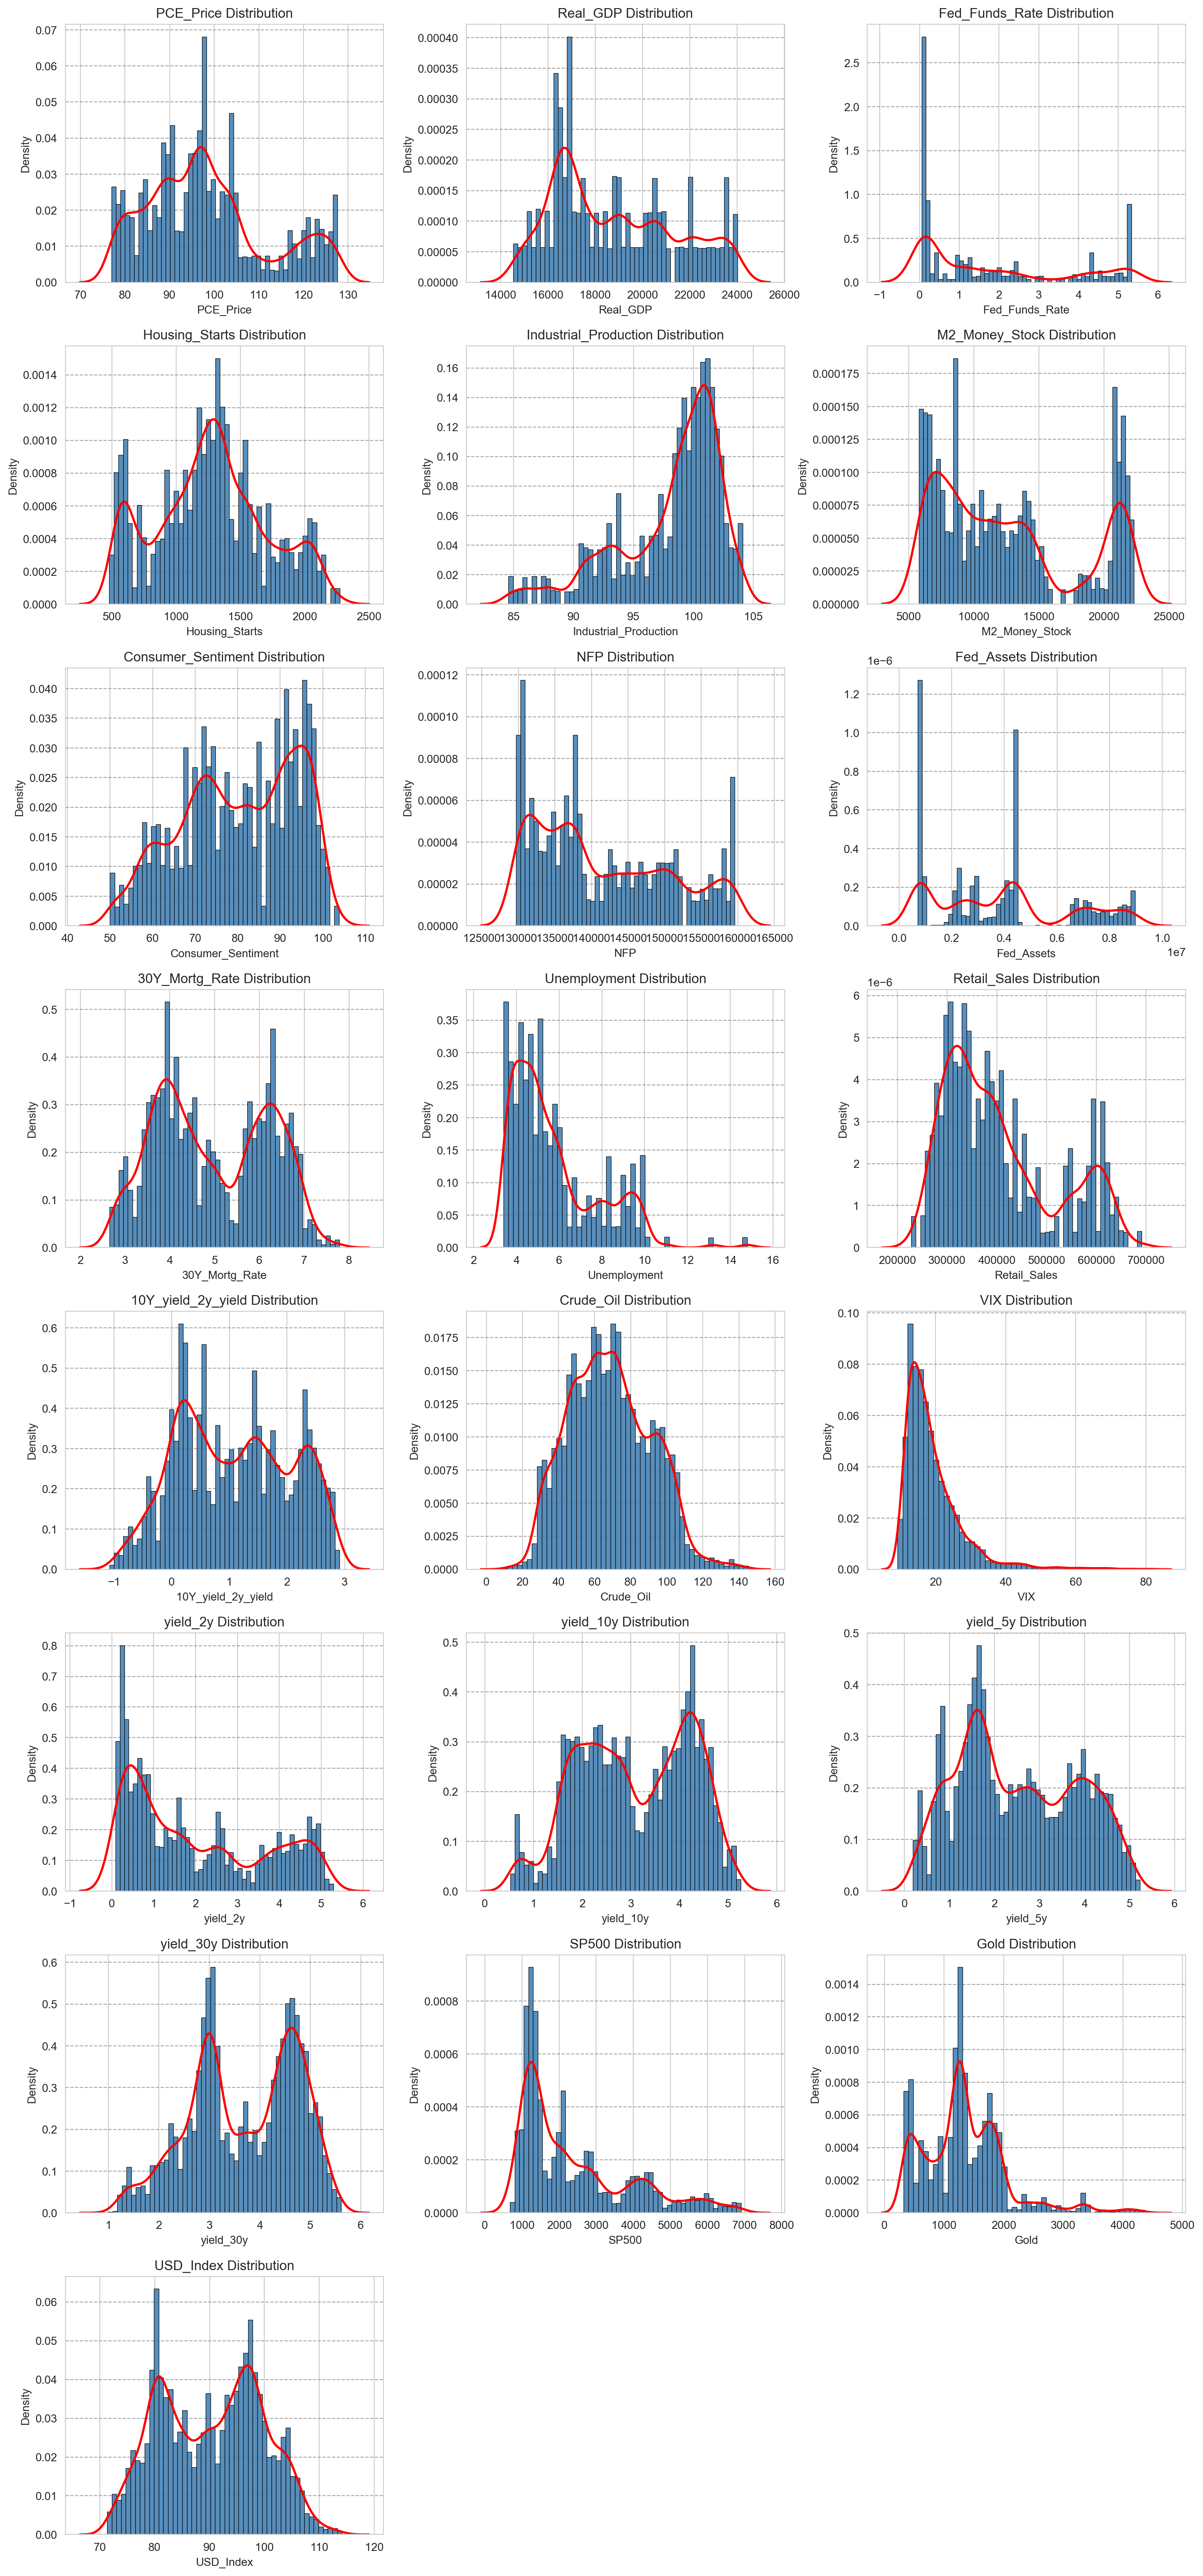

In [5]:
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns
cols_number = 3
rows = int(np.ceil(len(numeric_cols)/cols_number))

fig, axes = plt.subplots(nrows = rows, ncols = cols_number, figsize=(cols_number*5, rows*4))
axes = axes.flatten()  # flatten 2D array into 1D

for i, col in enumerate(numeric_cols):
    sns.histplot(data = df_raw[col], bins = 50, ax = axes[i], edgecolor = 'black', alpha = 0.9, color = 'steelblue', stat = 'density')
    sns.kdeplot(data = df_raw[col], color = 'red', ax = axes[i], linewidth = 2)
    axes[i].set_ylabel('Density')
    axes[i].set_title(f'{col} Distribution')
    axes[i].grid(True, axis='y', linestyle='--', color='gray', alpha=0.7)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

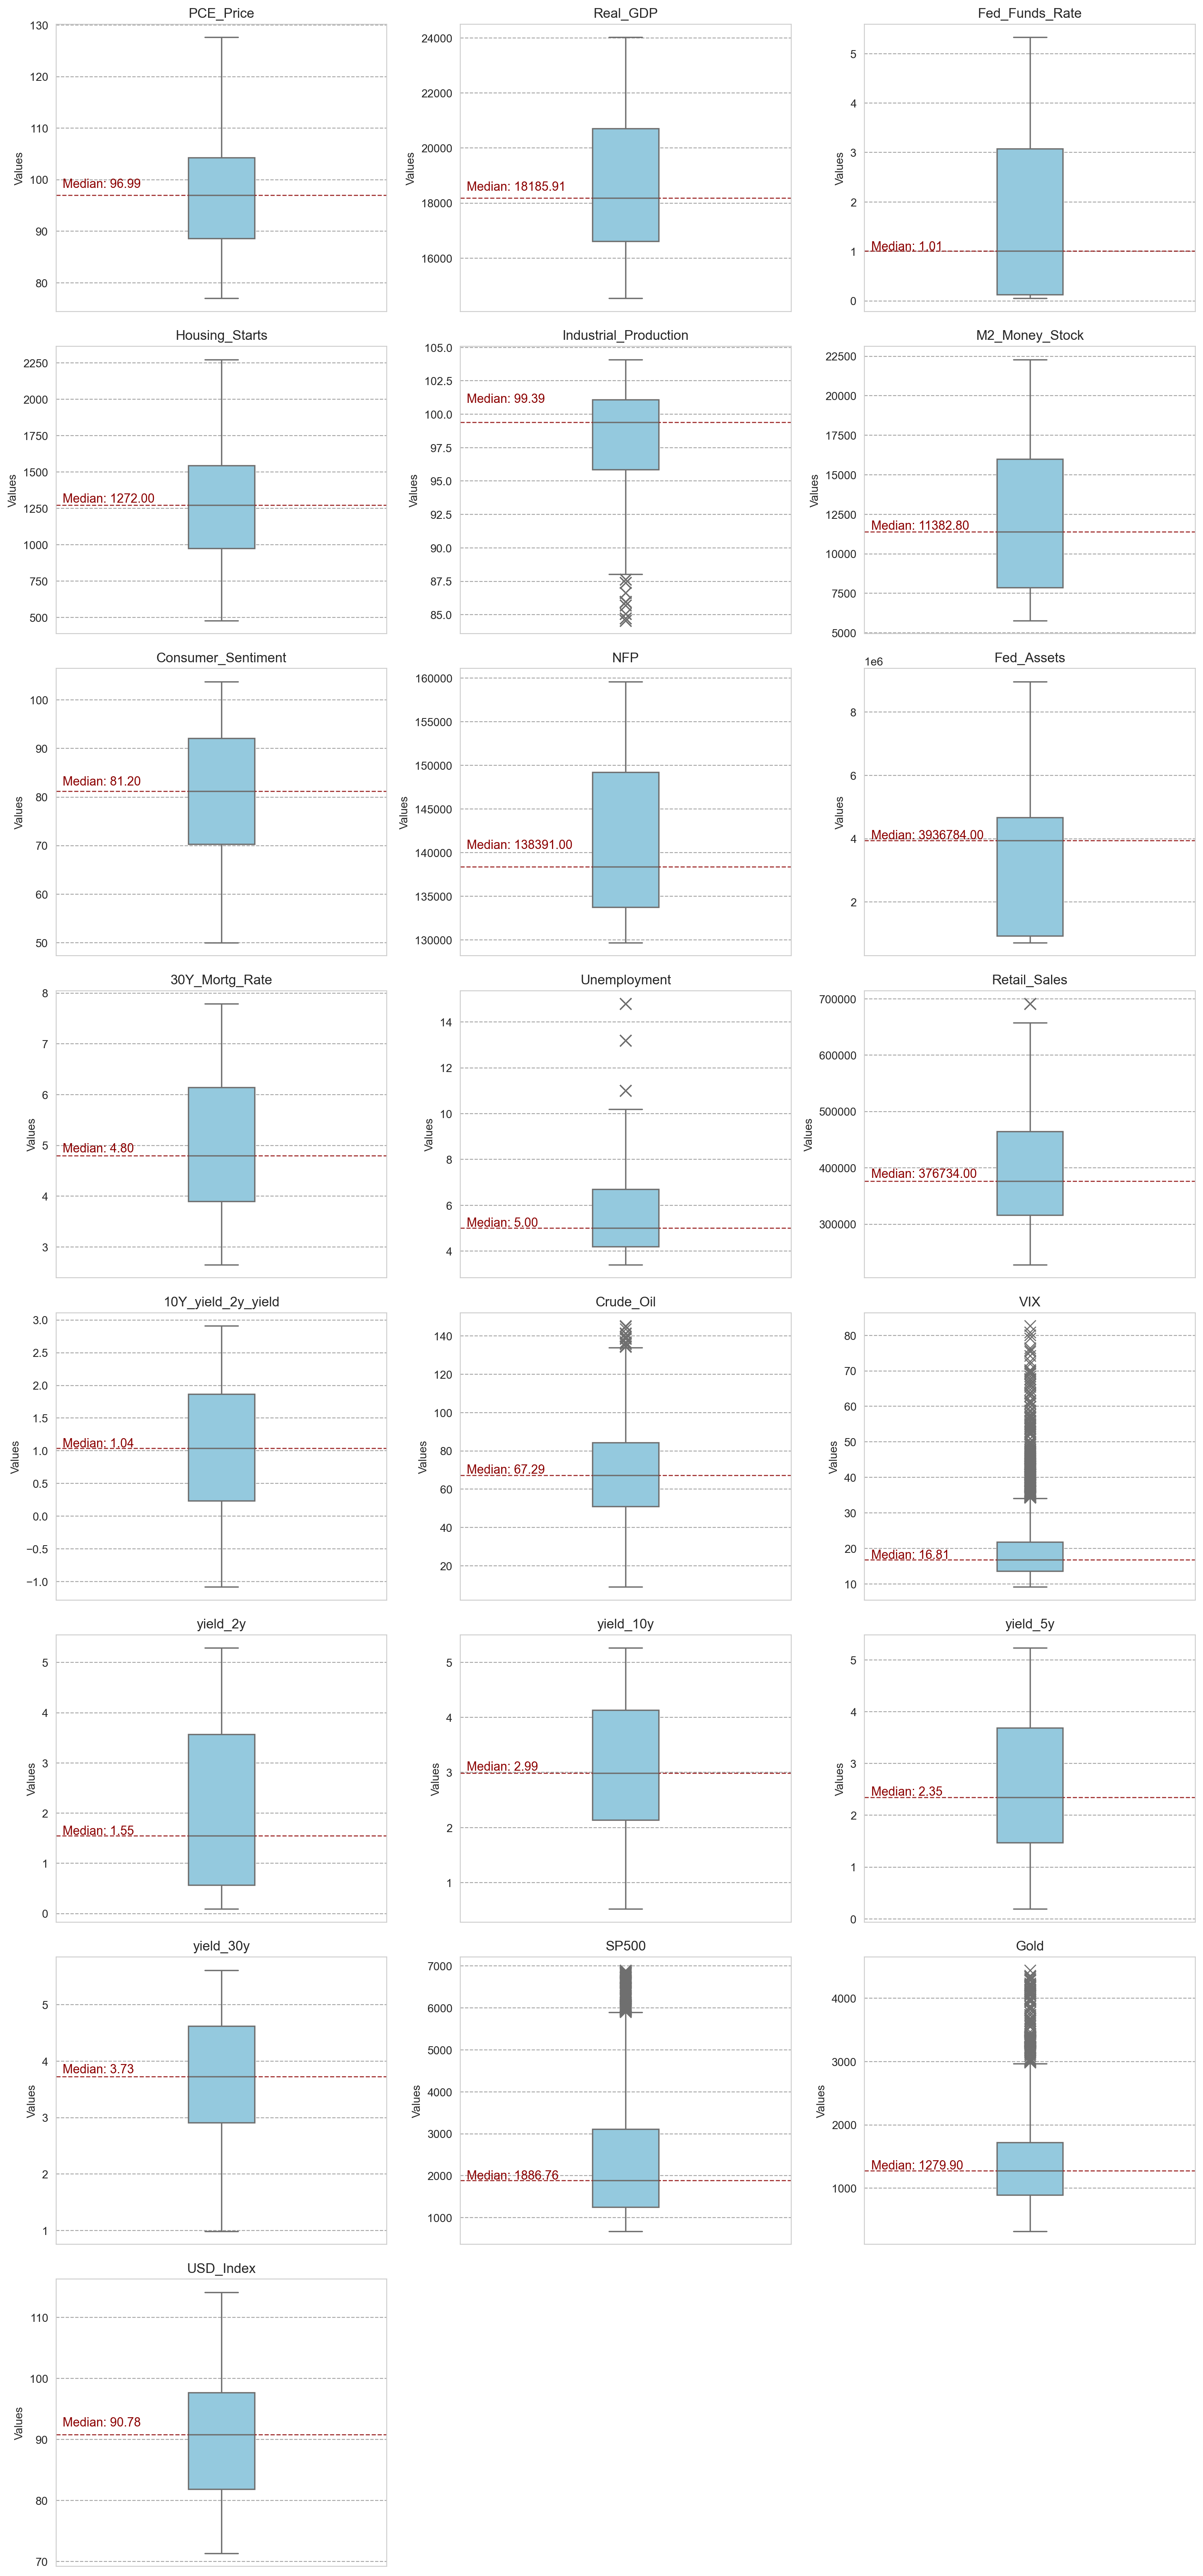

In [6]:
fig, axes = plt.subplots(nrows = rows, ncols = cols_number, figsize=(cols_number*5, rows*4))
axes = axes.flatten()  # flatten 2D array into 1D

for i, col in enumerate(numeric_cols):
    sns.boxplot(
    data = df_raw[col],
    ax = axes[i],
    color = 'skyblue',
    width = 0.2,
    linewidth = 1.2,
    whis = 1.5,
    flierprops=dict(marker='x', color='black', markersize=10)
    )
    
    median = df_raw[col].median()
    axes[i].axhline(
        median,
        color='darkred',
        linestyle='--',
        linewidth=1,
        alpha=0.8
    )
    axes[i].annotate(
        f'Median: {median:.2f}',
        xy=(0.02, median + (0.015 * abs(median))),
        xycoords=('axes fraction', 'data'),
        fontsize=11,
        color='darkred'
    )
    
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Values')
    axes[i].grid(True, axis='y', linestyle='--', color='gray', alpha=0.7)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### 6. Correlation Analysis

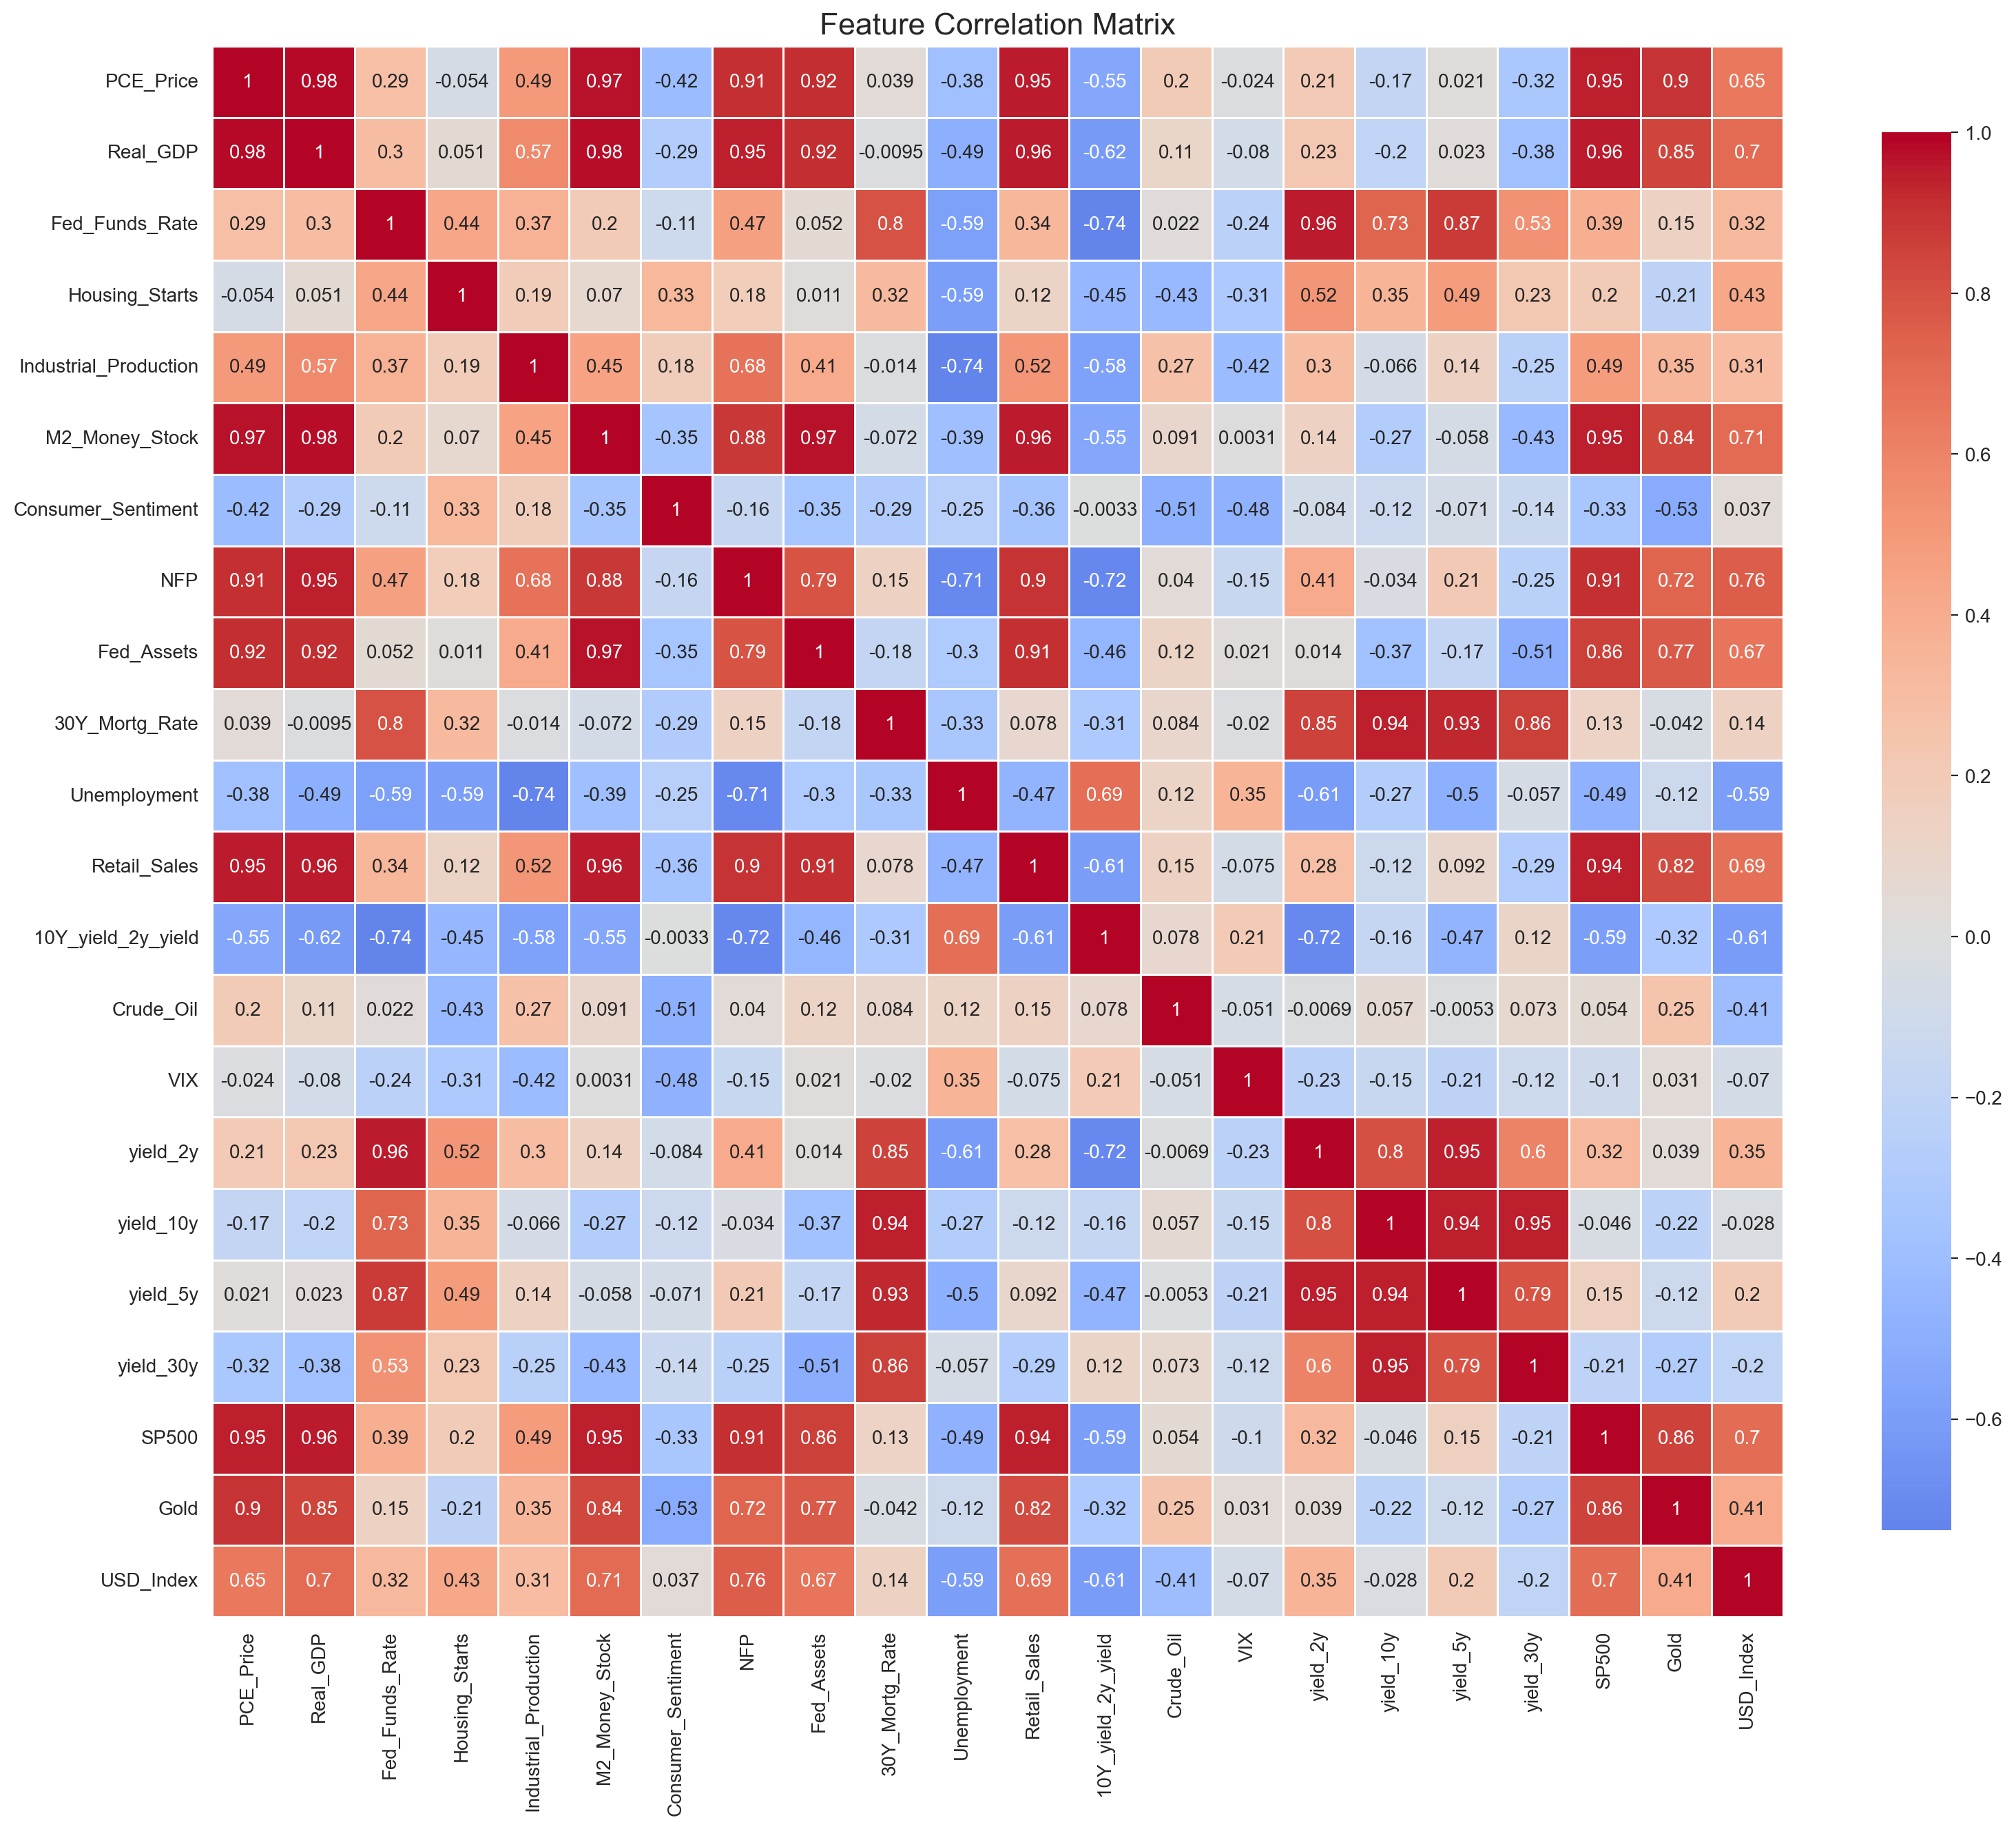

In [7]:
corr_matrix = df_raw[numeric_cols].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(data = corr_matrix, annot = True, cmap = 'coolwarm', center = 0,
            square = True, linewidths = 0.5, cbar_kws = {"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

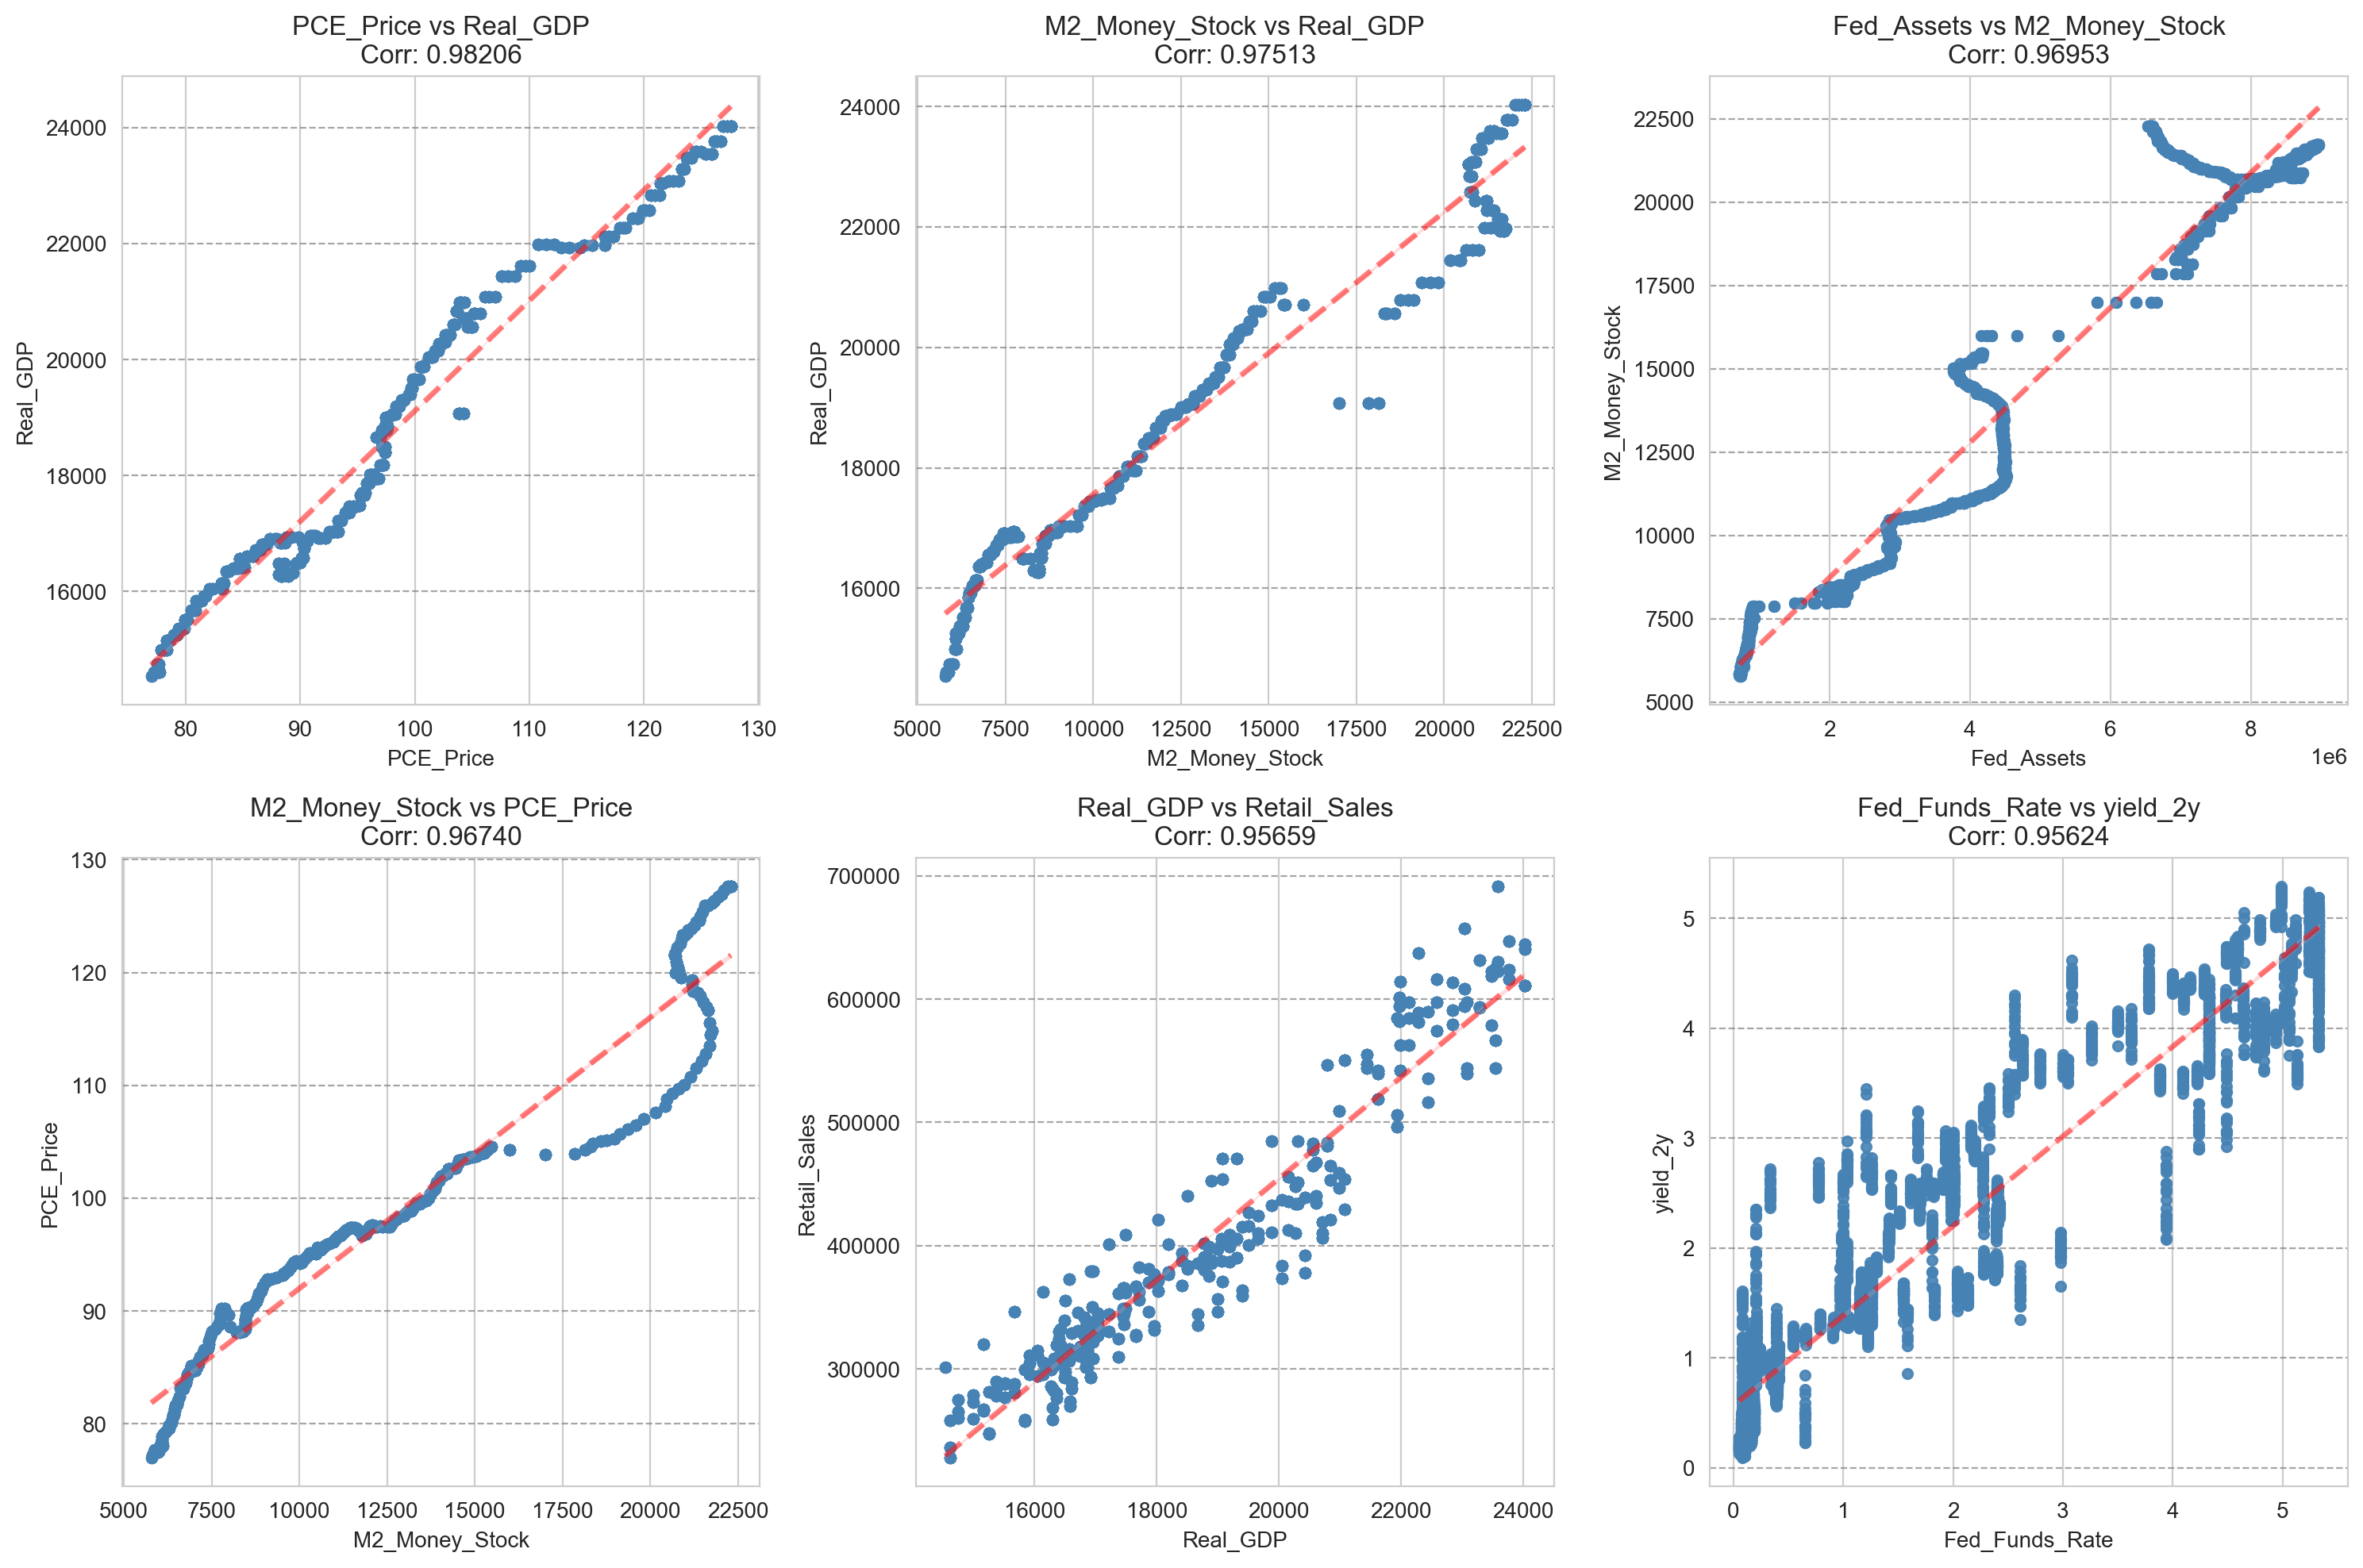

In [8]:
corr_signed = corr_matrix.unstack()
corr_pairs = corr_matrix.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1]
corr_pairs = corr_pairs.groupby(lambda x: tuple(sorted(x))).first().sort_values(ascending = False)
top_pairs = corr_pairs.head(6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, ((var1, var2), _) in enumerate(top_pairs.items()):
    corr_val = corr_signed.loc[(var1, var2)]
    sns.regplot(
        data = df_raw,
        x = var1,
        y = var2,
        ax = axes[i],
        scatter = True,
        color = 'red',
        line_kws={"linewidth": 2.5, "linestyle": "--", 'alpha': 0.5},
        scatter_kws={'color': 'steelblue', 'alpha': 0.9, 's': 20},
)
    axes[i].set_title(f'{var1} vs {var2}\nCorr: {corr_val:.5f}')
    axes[i].grid(True, axis='y', linestyle='--', color='gray', alpha=0.7)

plt.tight_layout()
plt.show()

#### 7. Time series overview for all indicators

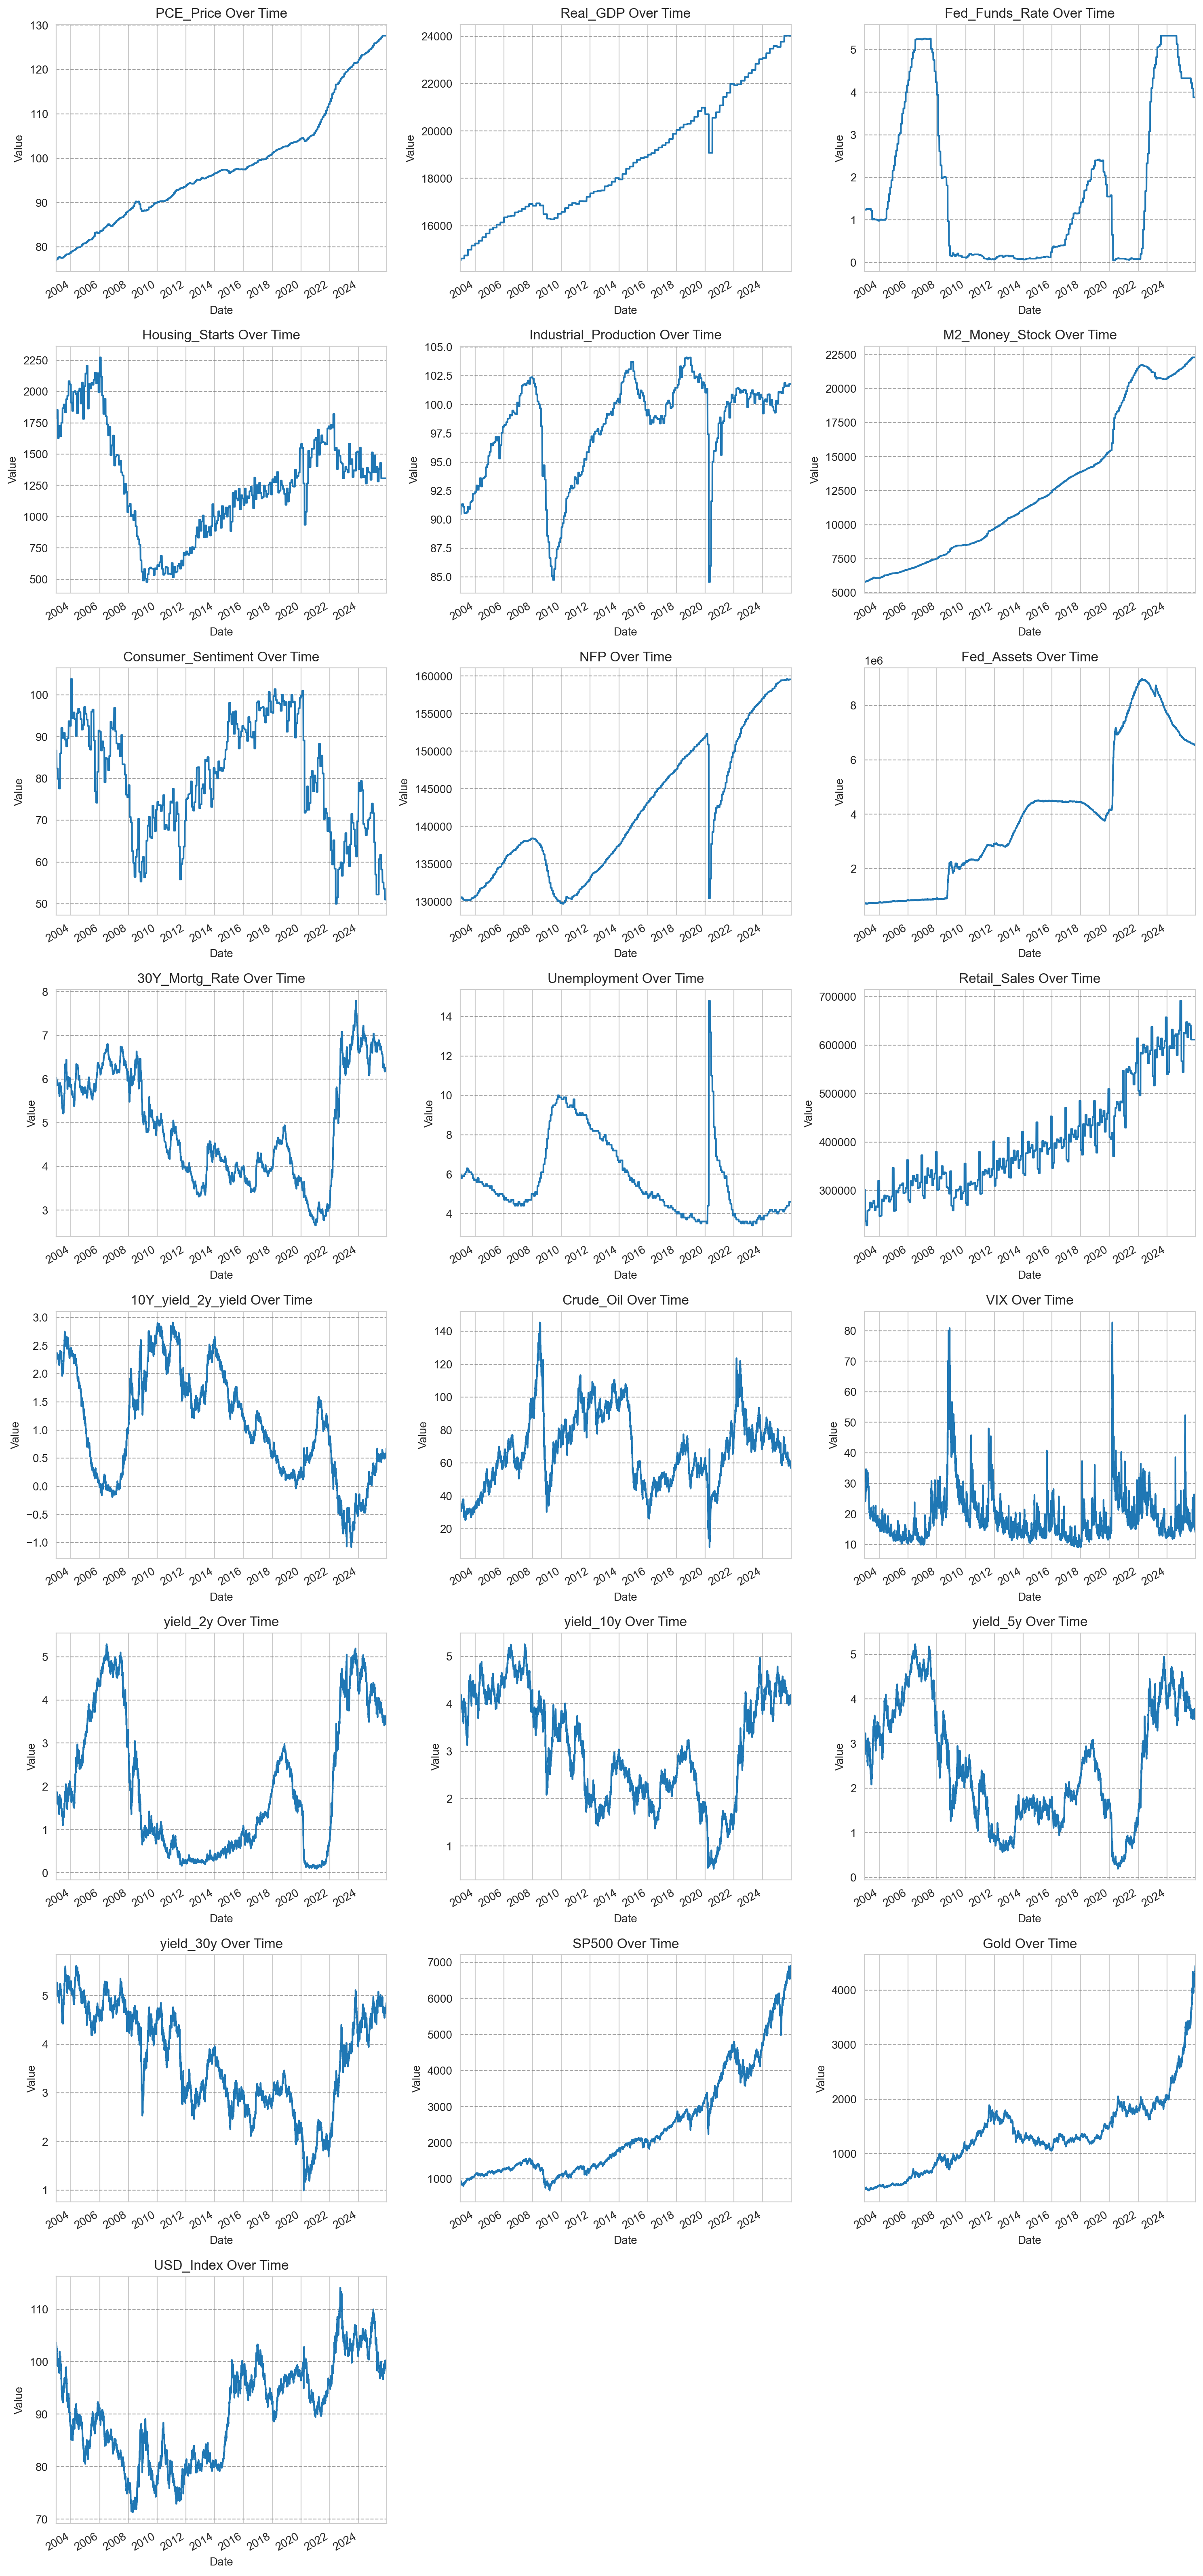

In [9]:
fig, axes = plt.subplots(nrows = rows, ncols = cols_number, figsize=(cols_number*5, rows*4))
axes = axes.flatten()  # flatten 2D array into 1D

for i, col in enumerate(numeric_cols):
    df_raw.plot(x = 'date', y = col, ax = axes[i], title = f'{col} Over Time')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Value')
    axes[i].xaxis.set_major_locator(mdates.AutoDateLocator(minticks=10, maxticks=15))
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].set_xlim(df_raw['date'].min(), df_raw['date'].max())
    axes[i].grid(True, axis='y', linestyle='--', color='gray', alpha=0.7)
    axes[i].get_legend().remove()

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### 8. Feature Engineering

In [10]:
df_engineered = loader.engineer_all_features(df = df_raw_offset.copy())

print(f"Engineered dataset shape: {df_engineered.shape}")
print(f"New features created: {df_engineered.shape[1] - df_raw_offset.shape[1]}")

# Display sample of new features
new_features = [col for col in df_engineered.columns if col not in df_raw_offset.columns]
df_engineered[['date'] + new_features[:10]].head()

Engineered dataset shape: (4591, 174)
New features created: 151


,date,USD_Index_ret_1d,USD_Index_ret_5d,USD_Index_ret_10d,USD_Index_ret_21d,USD_Index_ret_63d,USD_Index_ret_126d,USD_Index_ret_252d,USD_Index_vol_5d,USD_Index_vol_21d,USD_Index_vol_63d
1218,2007-10-01,0.002316,-0.008022,-0.022830,-0.035772,-0.042880,-0.059973,-0.089847,0.004241,0.003416,0.003246
1219,2007-10-02,0.005135,-0.000128,-0.011488,-0.030821,-0.038438,-0.058328,-0.086454,0.005082,0.003717,0.003325
1220,2007-10-03,0.003448,0.001019,-0.009206,-0.028561,-0.036424,-0.052917,-0.084692,0.005236,0.003831,0.003356
1221,2007-10-04,-0.001145,0.001787,-0.001273,-0.026544,-0.036582,-0.050798,-0.086592,0.005169,0.003808,0.003356
1222,2007-10-05,-0.002166,0.007591,-0.003690,-0.026842,-0.038315,-0.057641,-0.094054,0.003087,0.003811,0.003362


#### 9. Save Processed Data (Optional)

In [11]:
df_engineered.to_csv('../data/master_dataset_usa.csv', index=False)